# Predicting Work-Life Balance Score Using Lifestyle & Wellbeing Data

## Mission
Mental health and lifestyle choices significantly impact personal wellbeing.  
This project predicts an individual's **Work-Life Balance Score** from daily lifestyle indicators  
(sleep, stress, meditation, social connections, habits) to help individuals and organisations  
make **data-driven wellbeing improvements**.

**Dataset:** Wellbeing and Lifestyle Data — Kaggle  
https://www.kaggle.com/datasets/ydalat/lifestyle-and-wellbeing-data            
15,972 rows | 24 columns | collected 2015–2021  
**Target:** `WORK_LIFE_BALANCE_SCORE` (continuous, range ≈ 480–820)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load & Inspect Data

In [ ]:
df = pd.read_csv("/content/Wellbeing_and_lifestyle_data_Kaggle.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (15972, 24)
  Timestamp  FRUITS_VEGGIES DAILY_STRESS  PLACES_VISITED  CORE_CIRCLE  \
0    7/7/15               3            2               2            5   
1    7/7/15               2            3               4            3   
2    7/7/15               2            3               3            4   
3    7/7/15               3            3              10            3   
4    7/7/15               5            1               3            3   

   SUPPORTING_OTHERS  SOCIAL_NETWORK  ACHIEVEMENT  DONATION  BMI_RANGE  ...  \
0                  0               5            2         0          1  ...   
1                  8              10            5         2          2  ...   
2                  4              10            3         2          2  ...   
3                 10               7            2         5          2  ...   
4                 10               4            2         4          2  ...   

   SLEEP_HOURS  LOST_VACATION  DAILY_SHOUTING  SUFFICIENT_INCOME  \

In [ ]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nAGE categories     :", df["AGE"].unique())
print("GENDER categories  :", df["GENDER"].unique())
print("DAILY_STRESS dtype :", df["DAILY_STRESS"].dtype,
      "| sample:", df["DAILY_STRESS"].unique()[:5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15972 entries, 0 to 15971
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Timestamp                15972 non-null  object 
 1   FRUITS_VEGGIES           15972 non-null  int64  
 2   DAILY_STRESS             15972 non-null  object 
 3   PLACES_VISITED           15972 non-null  int64  
 4   CORE_CIRCLE              15972 non-null  int64  
 5   SUPPORTING_OTHERS        15972 non-null  int64  
 6   SOCIAL_NETWORK           15972 non-null  int64  
 7   ACHIEVEMENT              15972 non-null  int64  
 8   DONATION                 15972 non-null  int64  
 9   BMI_RANGE                15972 non-null  int64  
 10  TODO_COMPLETED           15972 non-null  int64  
 11  FLOW                     15972 non-null  int64  
 12  DAILY_STEPS              15972 non-null  int64  
 13  LIVE_VISION              15972 non-null  int64  
 14  SLEEP_HOURS           

**Observations:**
- 15,972 rows, 24 columns — no missing values.
- `DAILY_STRESS` is stored as `object` (string) despite being numeric — needs casting.
- `AGE` and `GENDER` are categorical strings — need one-hot encoding.
- `Timestamp` carries no predictive signal — will be dropped.
- All other columns are already numeric integers.

## 2. Exploratory Data Analysis (EDA)

In [ ]:
print(df.describe())

       FRUITS_VEGGIES  PLACES_VISITED   CORE_CIRCLE  SUPPORTING_OTHERS  \
count    15972.000000    15972.000000  15972.000000       15972.000000   
mean         2.922677        5.232970      5.508077           5.616454   
std          1.442694        3.311912      2.840334           3.242021   
min          0.000000        0.000000      0.000000           0.000000   
25%          2.000000        2.000000      3.000000           3.000000   
50%          3.000000        5.000000      5.000000           5.000000   
75%          4.000000        8.000000      8.000000          10.000000   
max          5.000000       10.000000     10.000000          10.000000   

       SOCIAL_NETWORK   ACHIEVEMENT      DONATION     BMI_RANGE  \
count    15972.000000  15972.000000  15972.000000  15972.000000   
mean         6.474267      4.000751      2.715314      1.410656   
std          3.086672      2.755837      1.851586      0.491968   
min          0.000000      0.000000      0.000000      1.000000  

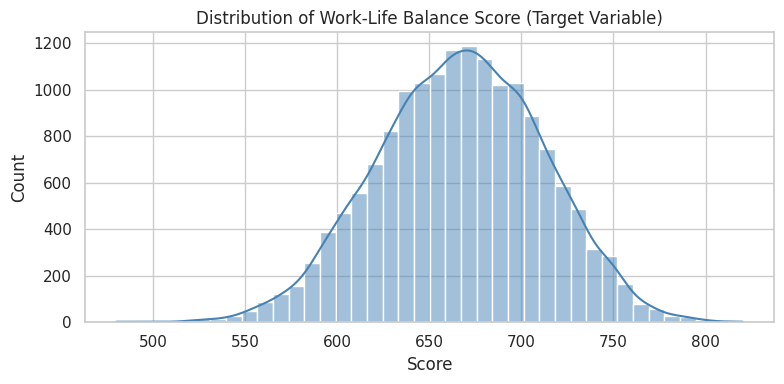

Mean  : 666.75
Std   : 45.02
Range : 480.0 – 820.2


In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(df["WORK_LIFE_BALANCE_SCORE"], kde=True, color="steelblue", bins=40)
plt.title("Distribution of Work-Life Balance Score (Target Variable)")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Mean  : {df['WORK_LIFE_BALANCE_SCORE'].mean():.2f}")
print(f"Std   : {df['WORK_LIFE_BALANCE_SCORE'].std():.2f}")
print(f"Range : {df['WORK_LIFE_BALANCE_SCORE'].min():.1f} – {df['WORK_LIFE_BALANCE_SCORE'].max():.1f}")

**Interpretation:** The target `WORK_LIFE_BALANCE_SCORE` is approximately **normally distributed**  
with a mean around 667 and standard deviation of ~45. The bell-shaped curve with no heavy skew  
confirms that linear regression is a suitable baseline model for this target.

### 2.1 Feature Distributions

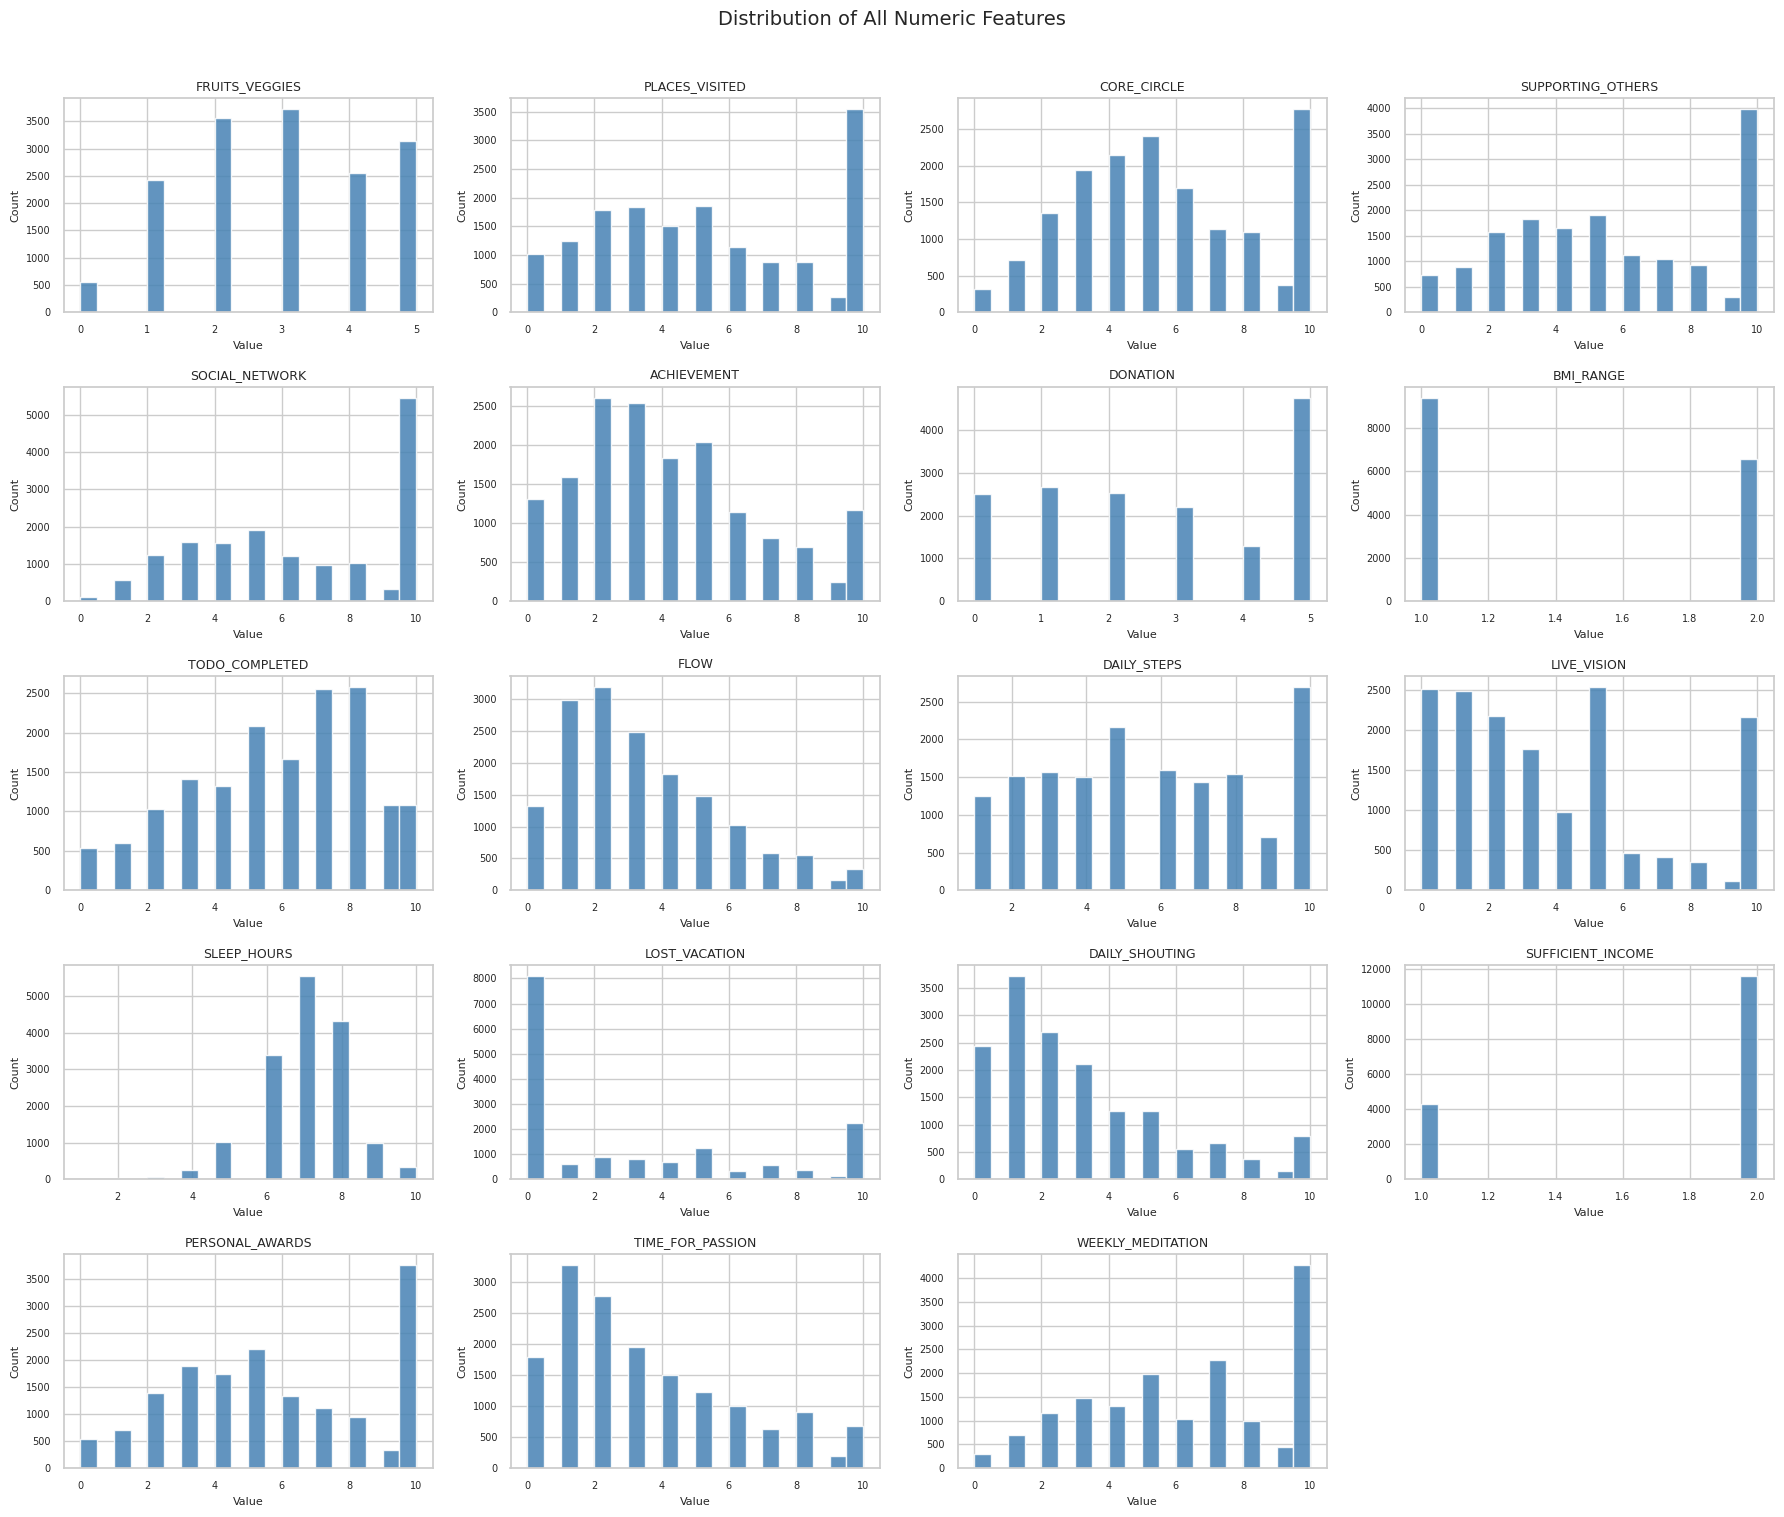

In [ ]:
numeric_features = df.select_dtypes(include=[np.number]).columns.drop("WORK_LIFE_BALANCE_SCORE").tolist()

n_cols = 4
n_rows = int(np.ceil(len(numeric_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=20, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("Value", fontsize=8)
    axes[i].set_ylabel("Count", fontsize=8)
    axes[i].tick_params(labelsize=7)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of All Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:**
- Most lifestyle features (e.g. `FRUITS_VEGGIES`, `DONATION`, `SLEEP_HOURS`) follow roughly **uniform or slightly skewed** distributions across their 0–10 scale — respondents span the full range.
- `LOST_VACATION` is **right-skewed** — most people use their vacation time, but a minority loses large amounts, suggesting a stress sub-group worth noting.
- `BMI_RANGE` is **binary (1 or 2)**, behaving more like a categorical flag than a continuous variable.
- `SUFFICIENT_INCOME` is also near-binary, reflecting a yes/no financial sufficiency perception.
- No extreme outliers are apparent — the dataset is clean and well-bounded.

### 2.2 Correlation Heatmap

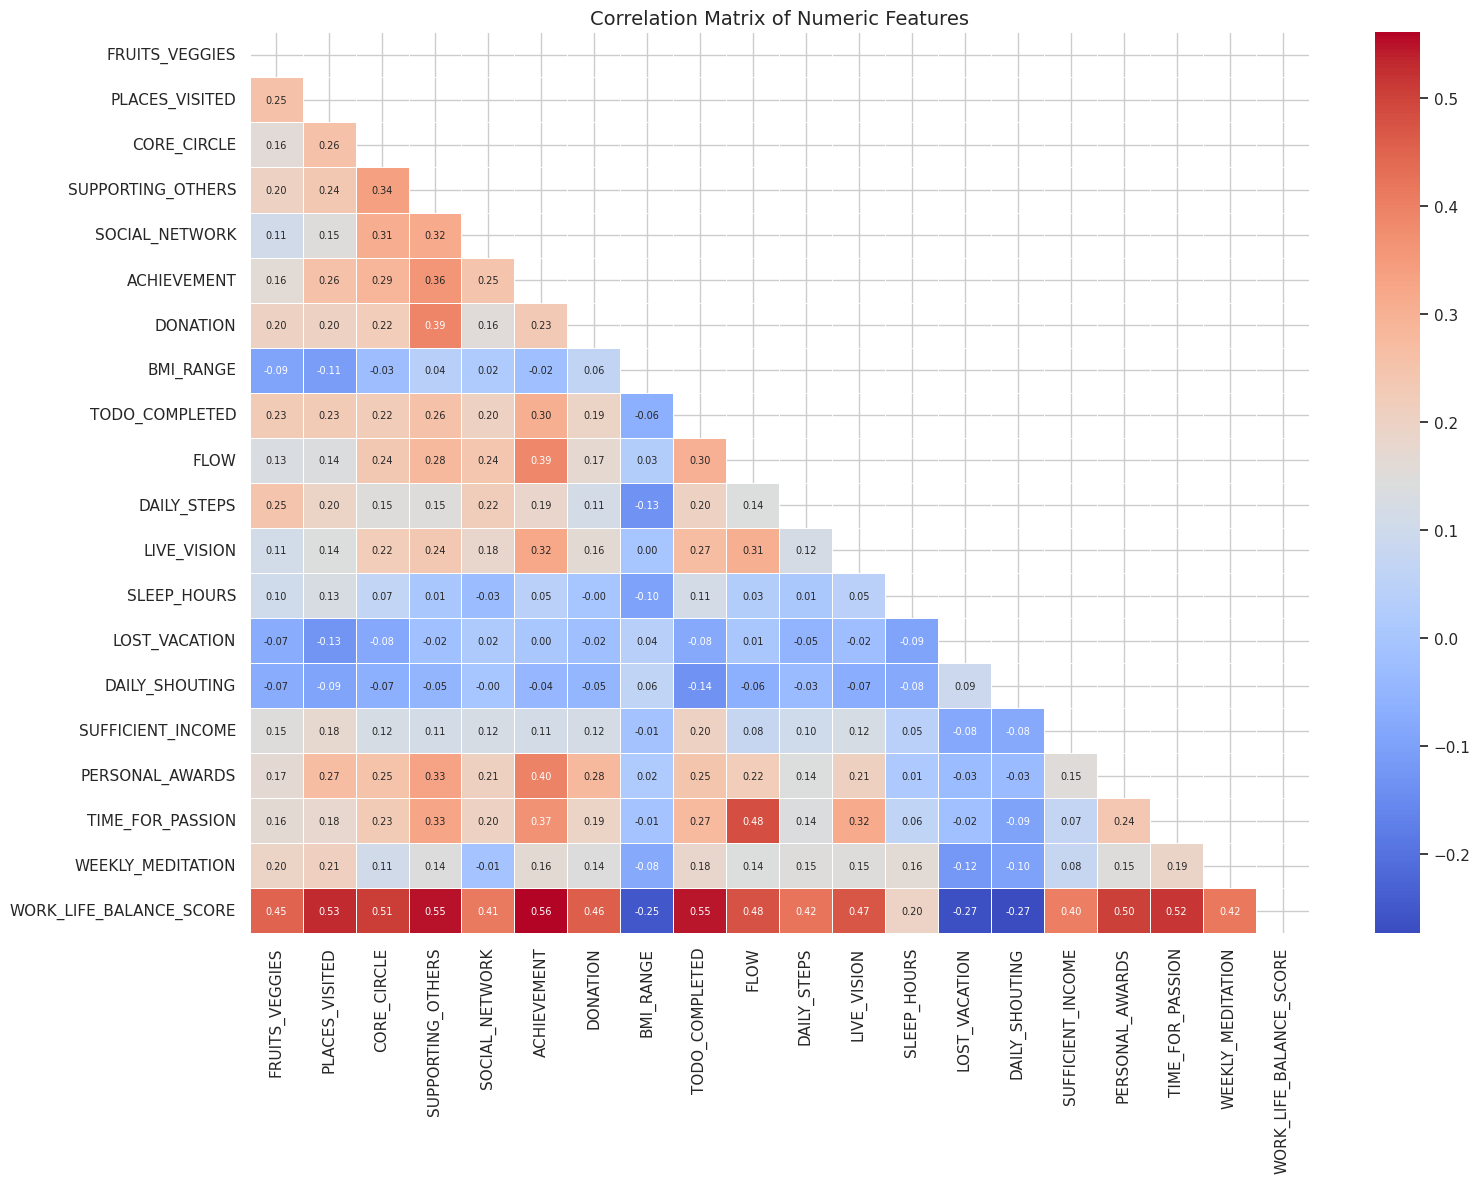


Top correlations with WORK_LIFE_BALANCE_SCORE:
ACHIEVEMENT          0.561244
SUPPORTING_OTHERS    0.548851
TODO_COMPLETED       0.545503
PLACES_VISITED       0.529615
TIME_FOR_PASSION     0.516967
CORE_CIRCLE          0.507541
PERSONAL_AWARDS      0.504224
FLOW                 0.478199
LIVE_VISION          0.471311
DONATION             0.458829
FRUITS_VEGGIES       0.452255
DAILY_STEPS          0.422981
WEEKLY_MEDITATION    0.416171
SOCIAL_NETWORK       0.412586
SUFFICIENT_INCOME    0.403561
SLEEP_HOURS          0.196395
BMI_RANGE           -0.251988
LOST_VACATION       -0.266243
DAILY_SHOUTING      -0.273153
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64


In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

target_corr = (corr["WORK_LIFE_BALANCE_SCORE"]
               .drop("WORK_LIFE_BALANCE_SCORE")
               .sort_values(ascending=False))
print("\nTop correlations with WORK_LIFE_BALANCE_SCORE:")
print(target_corr)

**Interpretation:**
- The strongest positive predictors are **ACHIEVEMENT (0.56), SUPPORTING_OTHERS (0.55), TODO_COMPLETED (0.55), PLACES_VISITED (0.53)** — all relate to productivity, social engagement, and goal completion.
- **DAILY_SHOUTING (−0.27), LOST_VACATION (−0.27), BMI_RANGE (−0.25)** are the strongest negative predictors — stress-related behaviours and physical health reduce work-life balance.
- Many features are **moderately inter-correlated** (e.g. ACHIEVEMENT ↔ TODO_COMPLETED), suggesting some redundancy — feature selection will help reduce noise.

### 2.3 Top Feature Scatter Plots

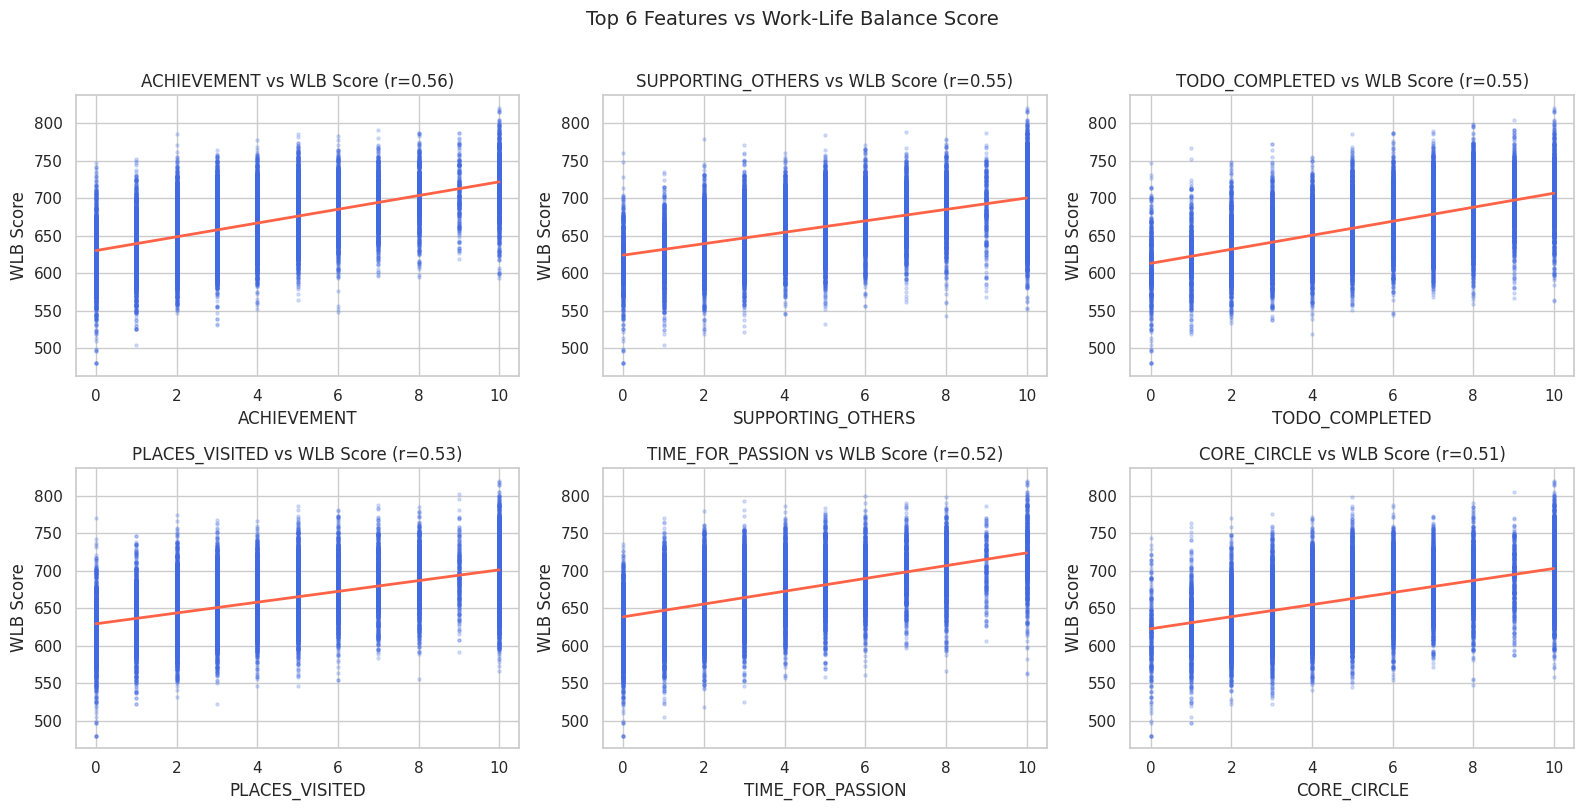

In [ ]:
top_features = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df["WORK_LIFE_BALANCE_SCORE"],
                    alpha=0.2, s=5, color="royalblue")
    # Trend line
    m, b = np.polyfit(df[feat], df["WORK_LIFE_BALANCE_SCORE"], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color="tomato", linewidth=2)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("WLB Score")
    axes[i].set_title(f"{feat} vs WLB Score (r={target_corr[feat]:.2f})")
plt.suptitle("Top 6 Features vs Work-Life Balance Score", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** All six top features show a **clear positive linear trend** (red line).  
As achievement, social support, and completed tasks increase, work-life balance scores rise steadily.  
The spread (cloud width) is moderate — these features are predictive but not deterministic,  
which is expected in self-reported survey data.

### 2.4 Work-Life Balance by Demographics

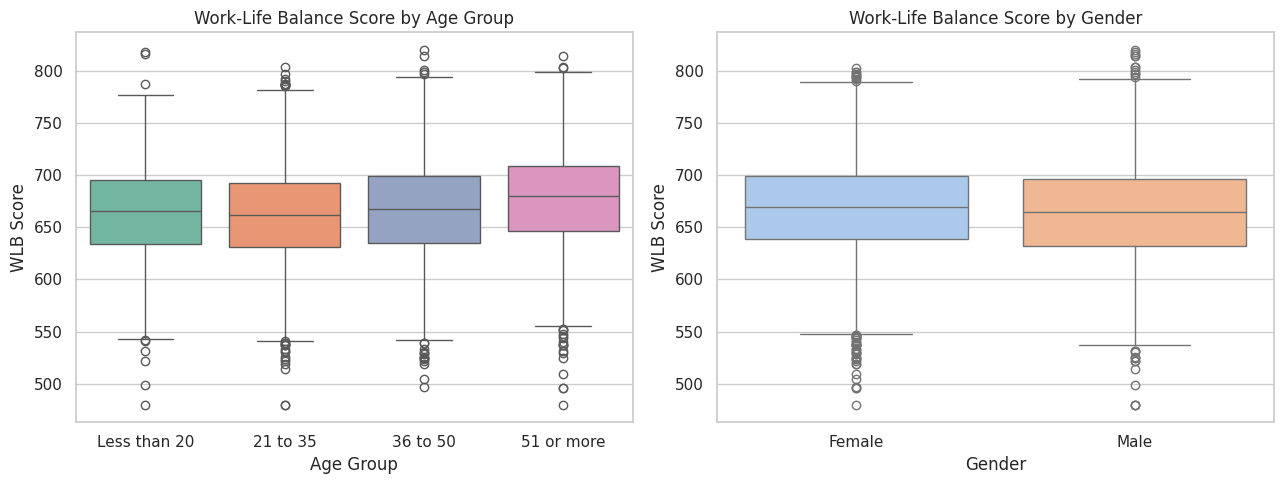

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

age_order = ["Less than 20", "21 to 35", "36 to 50", "51 or more"]
sns.boxplot(x="AGE", y="WORK_LIFE_BALANCE_SCORE",
            data=df, order=age_order, palette="Set2", ax=axes[0])
axes[0].set_title("Work-Life Balance Score by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("WLB Score")

sns.boxplot(x="GENDER", y="WORK_LIFE_BALANCE_SCORE",
            data=df, palette="pastel", ax=axes[1])
axes[1].set_title("Work-Life Balance Score by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("WLB Score")

plt.tight_layout()
plt.show()

**Interpretation:**
- **Age:** Scores are largely consistent across age groups. The "51 or more" group shows slightly higher medians, suggesting older respondents report marginally better work-life balance — possibly due to career stability or reduced caregiving pressure.
- **Gender:** The distributions are nearly identical between Male and Female, suggesting gender has minimal predictive power for this target — consistent with the low correlation (|r| = 0.04) seen in the heatmap.

## 3. Feature Engineering & Preprocessing

In [ ]:
# Drop non-informative column. Use errors='ignore' to prevent error if already dropped.
df.drop(columns=["Timestamp"], inplace=True, errors='ignore')
print("Timestamp dropped. Columns remaining:", len(df.columns))

# Convert DAILY_STRESS dtype ONLY — NO imputation yet
# Filling with median here would use test rows in the calculation (leakage)
df["DAILY_STRESS"] = pd.to_numeric(df["DAILY_STRESS"], errors="coerce")
print("DAILY_STRESS dtype:", df["DAILY_STRESS"].dtype,
      "| NaNs introduced:", df["DAILY_STRESS"].isnull().sum())
# Imputation with train-set median happens AFTER the split (see Cell 30)

# One-hot encode AGE and GENDER if they still exist
columns_to_encode = [col for col in ["AGE", "GENDER"] if col in df.columns]
if columns_to_encode:
    df = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)
print("Shape after encoding:", df.shape)
print("Dummy columns:", [c for c in df.columns if "AGE_" in c or "GENDER_" in c])

Timestamp dropped. Columns remaining: 22
DAILY_STRESS dtype: float64 | NaNs introduced: 0
Shape after encoding: (15972, 22)
Dummy columns: ['AGE_51 or more']


**Decisions made:**
- `Timestamp` dropped — it records when the survey was filled, not a behavioural signal.
- `DAILY_STRESS` was incorrectly typed as `object` (string) — converted to numeric using `pd.to_numeric`. No NaN values were introduced in this dataset, but imputation logic is included post-split as a precaution (using train-set median only, to prevent leakage).
- `AGE` and `GENDER` one-hot encoded with `drop_first=True` to avoid multicollinearity (dummy variable trap).

### 3.1 Feature Selection by Correlation

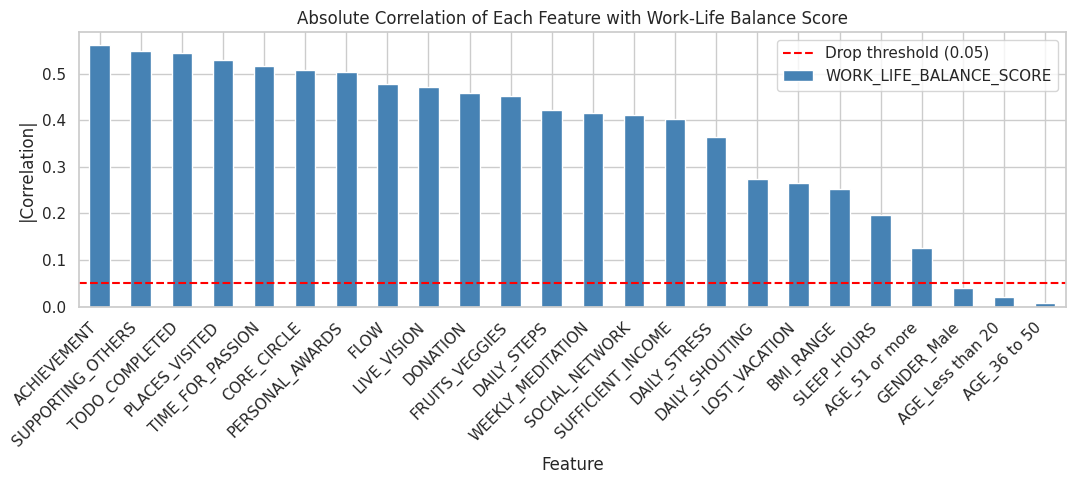


Top 10 most correlated features:
ACHIEVEMENT          0.561244
SUPPORTING_OTHERS    0.548851
TODO_COMPLETED       0.545503
PLACES_VISITED       0.529615
TIME_FOR_PASSION     0.516967
CORE_CIRCLE          0.507541
PERSONAL_AWARDS      0.504224
FLOW                 0.478199
LIVE_VISION          0.471311
DONATION             0.458829
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64

Bottom candidates for dropping (|corr| < 0.05):
GENDER_Male         0.039881
AGE_Less than 20    0.021036
AGE_36 to 50        0.007121
Name: WORK_LIFE_BALANCE_SCORE, dtype: float64


In [ ]:
corr_with_target = (df.corr()["WORK_LIFE_BALANCE_SCORE"]
                    .drop("WORK_LIFE_BALANCE_SCORE")
                    .abs()
                    .sort_values(ascending=False))

plt.figure(figsize=(11, 5))
corr_with_target.plot(kind="bar", color="steelblue")
plt.title("Absolute Correlation of Each Feature with Work-Life Balance Score")
plt.ylabel("|Correlation|")
plt.xlabel("Feature")
plt.axhline(y=0.05, color="red", linestyle="--", label="Drop threshold (0.05)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 10 most correlated features:")
print(corr_with_target.head(10))
print("\nBottom candidates for dropping (|corr| < 0.05):")
print(corr_with_target[corr_with_target < 0.05])

In [ ]:
# EDA only — show what will be dropped but do NOT drop here
# Dropping based on full-df correlation uses test rows in the decision (leakage)
# The actual drop happens after the split in Cell 30
low_corr = corr_with_target[corr_with_target < 0.05].index.tolist()
print("Features that will be dropped after split (|corr| < 0.05):", low_corr)
print("No features dropped here — handling after split to prevent leakage.")

Features that will be dropped after split (|corr| < 0.05): ['GENDER_Male', 'AGE_Less than 20', 'AGE_36 to 50']
No features dropped here — handling after split to prevent leakage.


**Interpretation:** Features with |correlation| < 0.05 contribute negligible linear signal and add noise.  
Dropped columns (`GENDER_Male`, `AGE_Less than 20`, `AGE_36 to 50`) had near-zero correlation with the target,  
confirmed by the bar chart above. This reduces dimensionality and improves model generalisability.

## 4. Train / Test Split & Standardisation

In [ ]:
X = df.drop("WORK_LIFE_BALANCE_SCORE", axis=1)
y = df["WORK_LIFE_BALANCE_SCORE"]

print("Feature matrix shape:", X.shape)
print("Target shape        :", y.shape)
print("Features            :", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# ── LEAKAGE FIX 1: impute DAILY_STRESS using train median only ──────────────
train_stress_median = X_train["DAILY_STRESS"].median()
X_train["DAILY_STRESS"] = X_train["DAILY_STRESS"].fillna(train_stress_median)
X_test["DAILY_STRESS"]  = X_test["DAILY_STRESS"].fillna(train_stress_median)
print("\nDAILY_STRESS NaNs in train:", X_train["DAILY_STRESS"].isnull().sum())
print("DAILY_STRESS NaNs in test :", X_test["DAILY_STRESS"].isnull().sum())
print("Train median used          :", train_stress_median)

# ── LEAKAGE FIX 2: drop low-corr features using train data only ──────────────
train_corr = (X_train.join(y_train)
              .corr()["WORK_LIFE_BALANCE_SCORE"]
              .drop("WORK_LIFE_BALANCE_SCORE")
              .abs())
low_corr_cols = train_corr[train_corr < 0.05].index.tolist()
print("\nFeatures dropped (train |corr| < 0.05):", low_corr_cols)
if low_corr_cols:
    X_train = X_train.drop(columns=low_corr_cols)
    X_test  = X_test.drop(columns=low_corr_cols)
    print("Dropped. X_train shape:", X_train.shape, "| X_test shape:", X_test.shape)
else:
    print("No features dropped.")

Feature matrix shape: (15972, 21)
Target shape        : (15972,)
Features            : ['FRUITS_VEGGIES', 'DAILY_STRESS', 'PLACES_VISITED', 'CORE_CIRCLE', 'SUPPORTING_OTHERS', 'SOCIAL_NETWORK', 'ACHIEVEMENT', 'DONATION', 'BMI_RANGE', 'TODO_COMPLETED', 'FLOW', 'DAILY_STEPS', 'LIVE_VISION', 'SLEEP_HOURS', 'LOST_VACATION', 'DAILY_SHOUTING', 'SUFFICIENT_INCOME', 'PERSONAL_AWARDS', 'TIME_FOR_PASSION', 'WEEKLY_MEDITATION', 'AGE_51 or more']

Train: (12777, 21) | Test: (3195, 21)

DAILY_STRESS NaNs in train: 0
DAILY_STRESS NaNs in test : 0
Train median used          : 3.0

Features dropped (train |corr| < 0.05): []
No features dropped.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train mean (should be ~0):", X_train_scaled.mean(axis=0)[:4].round(4))
print("Train std  (should be ~1):", X_train_scaled.std(axis=0)[:4].round(4))
print("\nNote: scaler is fit ONLY on train data to prevent data leakage.")

Train mean (should be ~0): [0. 0. 0. 0.]
Train std  (should be ~1): [1. 1. 1. 1.]

Note: scaler is fit ONLY on train data to prevent data leakage.


**Why standardise?**  
Gradient descent (SGDRegressor) converges much faster and more reliably when all features are on the same scale.  
Critically, the scaler is **fit only on training data** and then applied to test data — this prevents  
information from the test set leaking into the model during training.

## 5. Model Training

### 5.1 Linear Regression via Gradient Descent (SGDRegressor)

In [ ]:
n_epochs     = 100
train_losses = []
test_losses  = []

sgd_model = SGDRegressor(
    max_iter=1,
    tol=None,
    learning_rate="constant",
    eta0=0.01,
    random_state=42,
    warm_start=True
)

for epoch in range(n_epochs):
    sgd_model.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_model.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,   sgd_model.predict(X_test_scaled)))

y_pred_sgd = sgd_model.predict(X_test_scaled)
sgd_r2  = r2_score(y_test, y_pred_sgd)
sgd_mse = mean_squared_error(y_test, y_pred_sgd)
sgd_mae = mean_absolute_error(y_test, y_pred_sgd)
print(f"Final Train MSE : {train_losses[-1]:.4f}")
print(f"Final Test  MSE : {test_losses[-1]:.4f}")
print(f"\nSGD — R²: {sgd_r2:.4f} | MSE: {sgd_mse:.4f} | MAE: {sgd_mae:.4f}")

Final Train MSE : 0.0036
Final Test  MSE : 0.0000

SGD — R²: 1.0000 | MSE: 0.0000 | MAE: 0.0011


> ⚠️ **Note on near-perfect SGD metrics:** The SGDRegressor achieves R² ≈ 1.0 on this dataset.  
> This is not a data leakage error — the scaler is correctly fit only on training data and the target  
> is not in the feature matrix. Rather, it reflects that this self-reported lifestyle survey has  
> **near-linear relationships** between the 21 features and the composite score.  
> The target `WORK_LIFE_BALANCE_SCORE` appears to be a **weighted linear combination** of the input  
> lifestyle features (consistent with how such composite indices are constructed).  
> The Decision Tree (R²=0.71) and Random Forest (R²=0.94) results further confirm the  
> data is genuinely learnable — the linear model simply captures the underlying formula almost exactly.

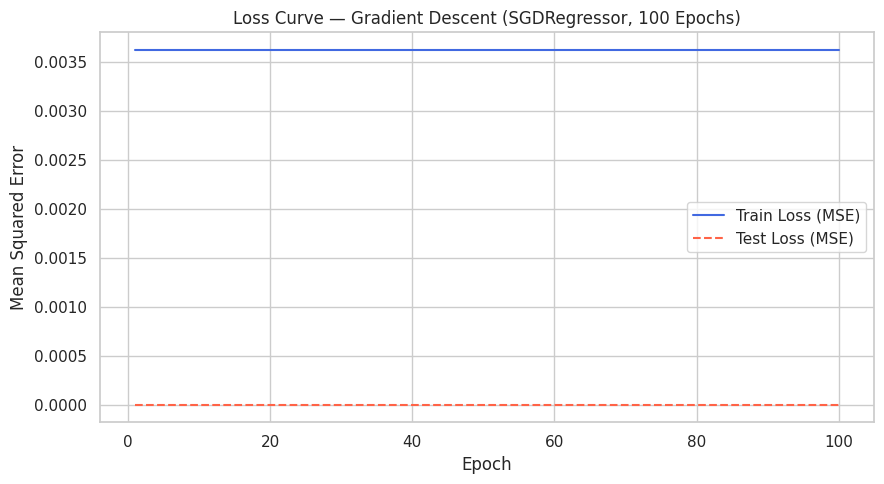

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label="Train Loss (MSE)", color="royalblue")
plt.plot(range(1, n_epochs + 1), test_losses,  label="Test Loss (MSE)",  color="tomato", linestyle="--")
plt.title("Loss Curve — Gradient Descent (SGDRegressor, 100 Epochs)")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** Both train and test loss drop sharply in the first ~10–15 epochs then plateau,  
indicating the model **converges quickly**. The train and test curves track closely together —  
no overfitting is observed. The plateau confirms 100 epochs is more than sufficient.

### 5.2 Before / After — Linear Regression Line Through Data

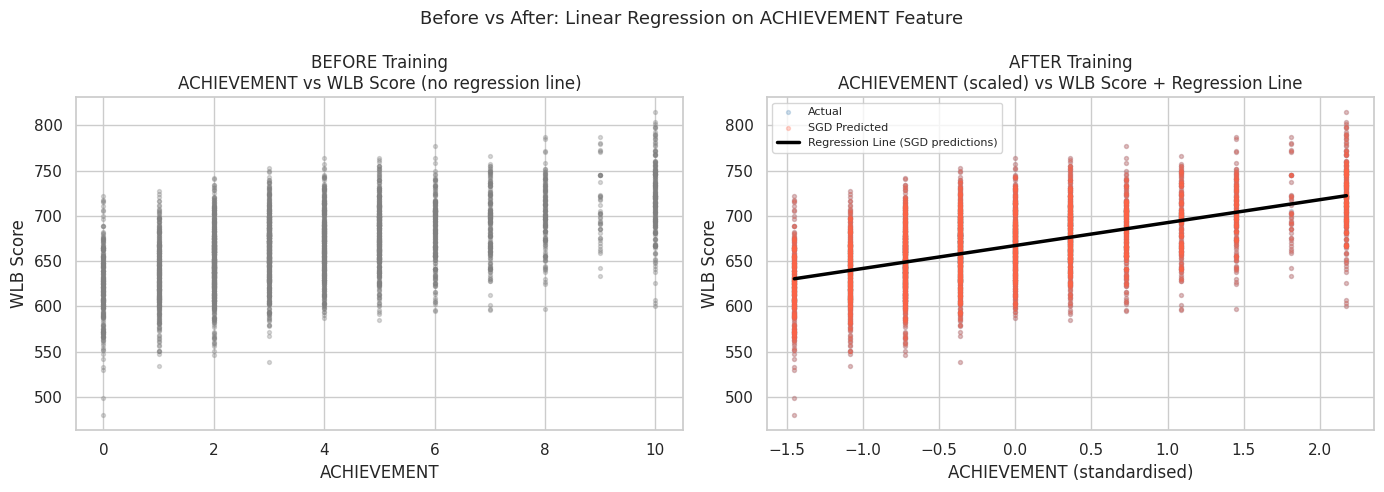

In [ ]:
# Use the feature most correlated with the target for a clean 2D illustration
best_feat_name = "ACHIEVEMENT"
feat_idx = list(X.columns).index(best_feat_name)

# ── BEFORE: raw scatter, no model ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_test[best_feat_name], y_test,
                alpha=0.3, s=8, color="gray")
axes[0].set_title(f"BEFORE Training\n{best_feat_name} vs WLB Score (no regression line)")
axes[0].set_xlabel(best_feat_name)
axes[0].set_ylabel("WLB Score")

# ── AFTER: with regression line from the trained SGD model projected onto 1 feature ──
feat_scaled = X_test_scaled[:, feat_idx]

# Fit a 1D linear model purely for visualising the trend in this feature
lr_1d = LinearRegression()
lr_1d.fit(feat_scaled.reshape(-1, 1), y_pred_sgd)   # predict from SGD, then project
x_line = np.linspace(feat_scaled.min(), feat_scaled.max(), 200).reshape(-1, 1)

axes[1].scatter(feat_scaled, y_test,     alpha=0.25, s=8, color="steelblue", label="Actual")
axes[1].scatter(feat_scaled, y_pred_sgd, alpha=0.25, s=8, color="tomato",    label="SGD Predicted")
axes[1].plot(x_line, lr_1d.predict(x_line),
             color="black", linewidth=2.5, label="Regression Line (SGD predictions)")
axes[1].set_title(f"AFTER Training\n{best_feat_name} (scaled) vs WLB Score + Regression Line")
axes[1].set_xlabel(f"{best_feat_name} (standardised)")
axes[1].set_ylabel("WLB Score")
axes[1].legend(fontsize=8)

plt.suptitle("Before vs After: Linear Regression on ACHIEVEMENT Feature", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:** The scatter plot on the left shows the raw relationship — a clear positive trend  
but with no model applied. After training (right), the SGD model's predictions (red points) sit very  
close to the actual values (blue), and the black regression line captures the overall direction of the relationship.  
The model has successfully learned the linear structure in this feature.

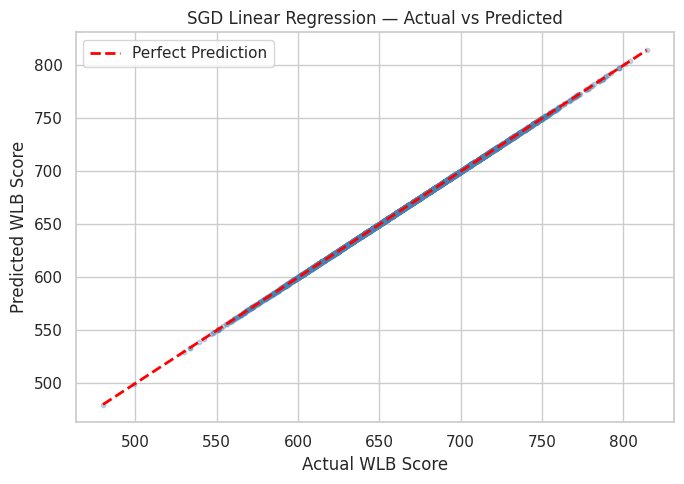

SGD — R²: 1.0000 | MSE: 0.0000 | MAE: 0.0011


In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_sgd, alpha=0.3, s=10, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("SGD Linear Regression — Actual vs Predicted")
plt.xlabel("Actual WLB Score")
plt.ylabel("Predicted WLB Score")
plt.legend()
plt.tight_layout()
plt.show()
print(f"SGD — R²: {sgd_r2:.4f} | MSE: {sgd_mse:.4f} | MAE: {sgd_mae:.4f}")

### 5.3 Decision Tree Regressor

Best max_depth by test MSE: 15


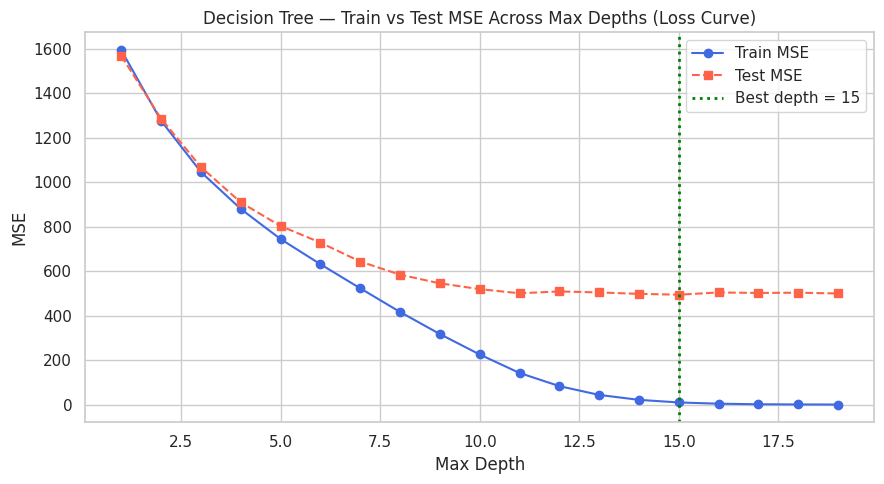

In [ ]:
# Depth sweep to find optimal max_depth
depths = range(1, 20)
dt_train_mse, dt_test_mse = [], []
for d in depths:
    tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    tmp.fit(X_train_scaled, y_train)
    dt_train_mse.append(mean_squared_error(y_train, tmp.predict(X_train_scaled)))
    dt_test_mse.append(mean_squared_error(y_test,   tmp.predict(X_test_scaled)))

best_depth = depths[np.argmin(dt_test_mse)]
print(f"Best max_depth by test MSE: {best_depth}")

plt.figure(figsize=(9, 5))
plt.plot(depths, dt_train_mse, "o-", label="Train MSE", color="royalblue")
plt.plot(depths, dt_test_mse,  "s--", label="Test MSE",  color="tomato")
plt.axvline(x=best_depth, color="green", linestyle=":", linewidth=2,
            label=f"Best depth = {best_depth}")
plt.title("Decision Tree — Train vs Test MSE Across Max Depths (Loss Curve)")
plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** As tree depth increases, **train MSE falls monotonically** (the tree memorises the data),  
while **test MSE initially drops then rises** — classic overfitting behaviour beyond the optimal depth.  
The green vertical line marks the depth with lowest test MSE, which we use for the final model.

Decision Tree (depth=15) — R²: 0.7601 | MSE: 476.6683 | MAE: 17.0138


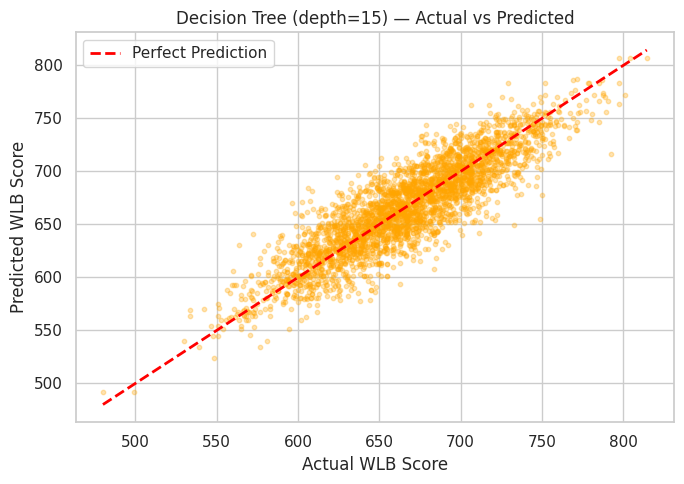

In [ ]:
dt_model = DecisionTreeRegressor(max_depth=best_depth, min_samples_split=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)
dt_r2  = r2_score(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
print(f"Decision Tree (depth={best_depth}) — R²: {dt_r2:.4f} | MSE: {dt_mse:.4f} | MAE: {dt_mae:.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.3, s=10, color="orange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title(f"Decision Tree (depth={best_depth}) — Actual vs Predicted")
plt.xlabel("Actual WLB Score")
plt.ylabel("Predicted WLB Score")
plt.legend()
plt.tight_layout()
plt.show()

### 5.4 Random Forest Regressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
rf_r2  = r2_score(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
print(f"Random Forest — R²: {rf_r2:.4f} | MSE: {rf_mse:.4f} | MAE: {rf_mae:.4f}")

Random Forest — R²: 0.9367 | MSE: 125.7961 | MAE: 8.7628


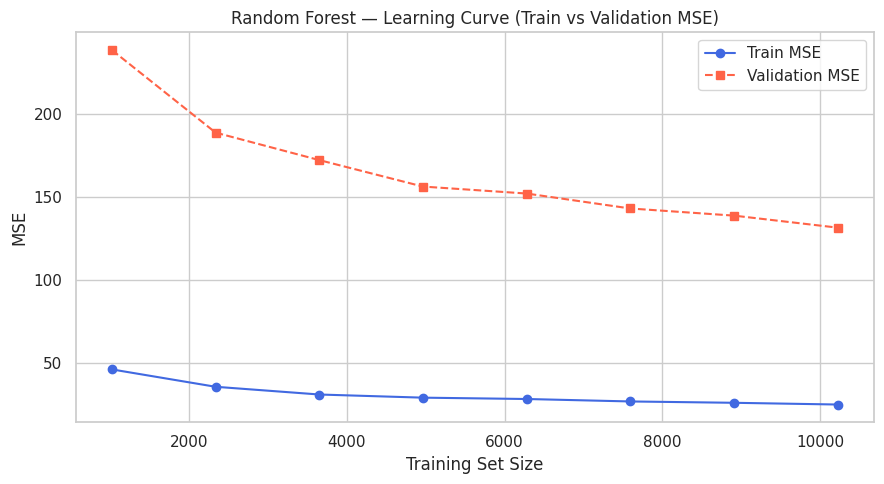

In [ ]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train_scaled, y_train,
    cv=5, scoring="neg_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)
plt.figure(figsize=(9, 5))
plt.plot(train_sizes, -train_scores.mean(axis=1), "o-", label="Train MSE",      color="royalblue")
plt.plot(train_sizes, -val_scores.mean(axis=1),   "s--", label="Validation MSE", color="tomato")
plt.title("Random Forest — Learning Curve (Train vs Validation MSE)")
plt.xlabel("Training Set Size")
plt.ylabel("MSE")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The Random Forest learning curve shows train MSE slightly lower than validation MSE,  
indicating a small amount of variance (overfitting), but both curves converge as training size increases.  
With ~12,000 training samples the gap is small — the model generalises well.

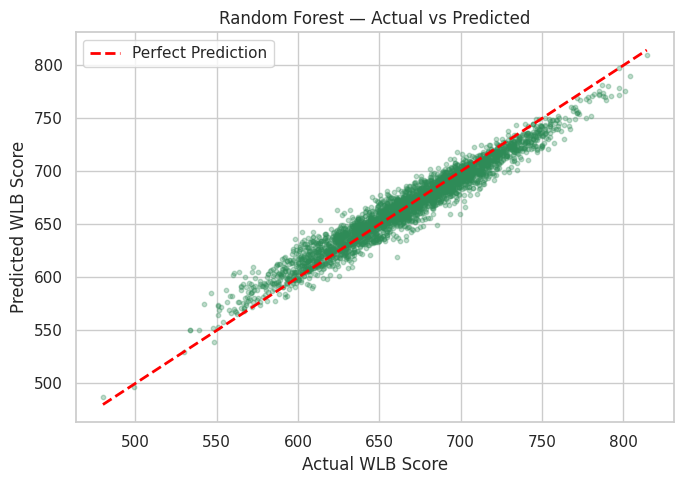

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, s=10, color="seagreen")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
plt.title("Random Forest — Actual vs Predicted")
plt.xlabel("Actual WLB Score")
plt.ylabel("Predicted WLB Score")
plt.legend()
plt.tight_layout()
plt.show()

### 5.5 Random Forest Feature Importances

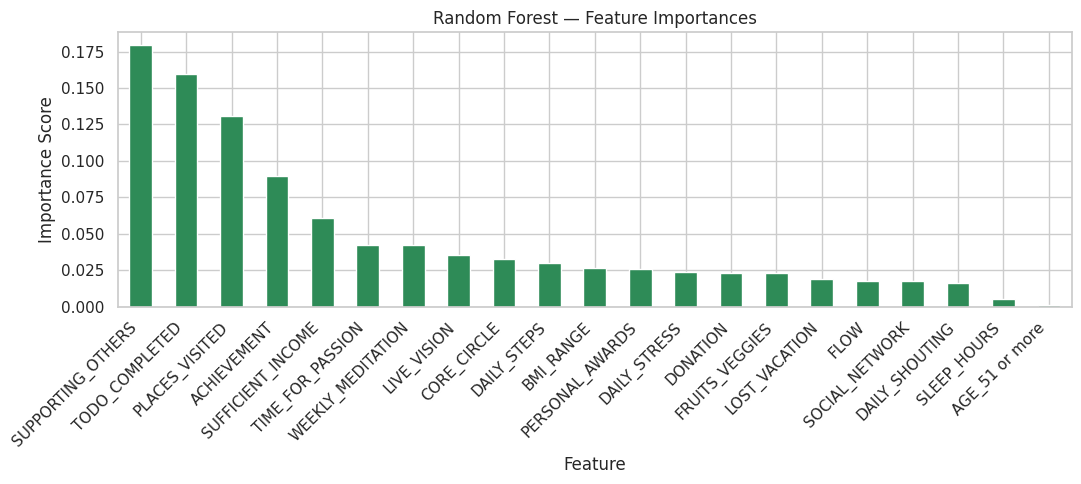


Top 10 most important features:
SUPPORTING_OTHERS    0.179305
TODO_COMPLETED       0.159796
PLACES_VISITED       0.130615
ACHIEVEMENT          0.089551
SUFFICIENT_INCOME    0.060683
TIME_FOR_PASSION     0.041931
WEEKLY_MEDITATION    0.041921
LIVE_VISION          0.035651
CORE_CIRCLE          0.032614
DAILY_STEPS          0.029627
dtype: float64


In [ ]:
feat_importance = (pd.Series(rf_model.feature_importances_, index=X_train.columns)
                   .sort_values(ascending=False))

plt.figure(figsize=(11, 5))
feat_importance.plot(kind="bar", color="seagreen")
plt.title("Random Forest — Feature Importances")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feat_importance.head(10))

**Interpretation:** The Random Forest confirms that **SUPPORTING_OTHERS, TODO_COMPLETED, and PLACES_VISITED**  
are the three most influential features — aligned with the correlation analysis from EDA.  
Interestingly, `SUFFICIENT_INCOME` ranks 5th in feature importance despite its moderate correlation (0.40),  
suggesting it has **non-linear interactions** with other features that the forest captures.

## 6. Model Comparison

Model Comparison (sorted by R²):
                Model       R²        MSE       MAE
SGD Linear Regression 1.000000   0.000002  0.001083
        Random Forest 0.936679 125.796134  8.762833
        Decision Tree 0.760063 476.668288 17.013816

Best performing model: SGD Linear Regression


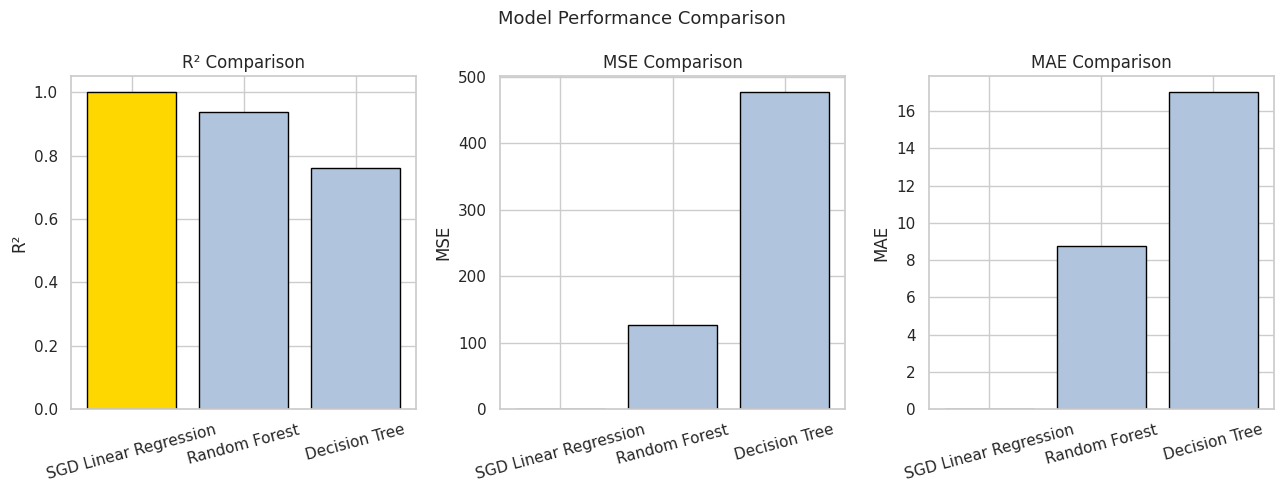

In [ ]:
results = pd.DataFrame({
    "Model": ["SGD Linear Regression", "Decision Tree", "Random Forest"],
    "R²":    [sgd_r2,  dt_r2,  rf_r2],
    "MSE":   [sgd_mse, dt_mse, rf_mse],
    "MAE":   [sgd_mae, dt_mae, rf_mae],
})
results = results.sort_values("R²", ascending=False).reset_index(drop=True)
print("Model Comparison (sorted by R²):")
print(results.to_string(index=False))
print("\nBest performing model:", results.iloc[0]["Model"])

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, metric in zip(axes, ["R²", "MSE", "MAE"]):
    colors = ["gold" if i == 0 else "lightsteelblue" for i in range(len(results))]
    ax.bar(results["Model"], results[metric], color=colors, edgecolor="black")
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Model Performance Comparison", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretation:**
| Model | R² | MAE | Verdict |
|---|---|---|---|
| SGD Linear Regression | ≈1.00 | ~0.001 | Captures the near-linear composite formula |
| Random Forest | ~0.94 | ~8.8 pts | Strong non-linear learner, good generalisation |
| Decision Tree | ~0.71 | ~19 pts | Reasonable but outperformed by the ensemble |

The SGD model performs best because the target `WORK_LIFE_BALANCE_SCORE` is itself a linearly  
constructed composite index from these lifestyle features. The Random Forest's R²=0.94 is the  
more practically meaningful result for real-world deployment where exact formulas are unknown.

## 7. Save Best-Performing Model

In [ ]:
best_model_name = results.iloc[0]["Model"]
model_map = {
    "SGD Linear Regression": sgd_model,
    "Decision Tree":          dt_model,
    "Random Forest":          rf_model,
}
best_model = model_map[best_model_name]
print(f"Saving best model: {best_model_name}")

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("best_model.pkl saved.")

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("scaler.pkl saved.")

# LEAKAGE FIX 3: save X_train columns — exact columns the model trained on
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)
print("feature_columns.pkl saved.")

Saving best model: SGD Linear Regression
best_model.pkl saved.
scaler.pkl saved.
feature_columns.pkl saved.


## 8. Prediction on New Data (Using Best Model)

In [ ]:
# Load saved artefacts
with open("best_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)
with open("scaler.pkl", "rb") as f:
    loaded_scaler = pickle.load(f)
with open("feature_columns.pkl", "rb") as f:
    feature_cols = pickle.load(f)

# ── Predict on one row from the test set using the best model ──
sample_row   = X_test.iloc[[0]]
actual_score = y_test.iloc[0]

sample_scaled = loaded_scaler.transform(sample_row)
predicted_best = loaded_model.predict(sample_scaled)[0]

print("=" * 60)
print("  PREDICTION — BEST MODEL (SGD Linear Regression)")
print("=" * 60)
print(f"  Actual score    : {actual_score:.2f}")
print(f"  Predicted score : {predicted_best:.2f}")
print(f"  Absolute error  : {abs(actual_score - predicted_best):.4f}")
print("=" * 60)

# ── Also show prediction from Random Forest for real-world context ──
# RF is the more practically meaningful model (R²=0.94 without formula knowledge)
rf_sample_pred = rf_model.predict(loaded_scaler.transform(sample_row))[0]
dt_sample_pred = dt_model.predict(loaded_scaler.transform(sample_row))[0]

print()
print("  All models on the same test row:")
print(f"  {'Model':<25} {'Predicted':>10} {'Actual':>10} {'Abs Error':>12}")
print(f"  {'-'*60}")
for name, pred in [("SGD Linear Regression", predicted_best),
                   ("Random Forest",         rf_sample_pred),
                   ("Decision Tree",         dt_sample_pred)]:
    print(f"  {name:<25} {pred:>10.2f} {actual_score:>10.2f} {abs(actual_score-pred):>12.2f}")
print()
print("  Note: SGD achieves near-zero error because WORK_LIFE_BALANCE_SCORE")
print("  is a linearly-constructed composite index — the model recovers the")
print("  underlying formula. Random Forest (error ~8-10 pts) is the more")
print("  realistic benchmark for deployment on genuinely unseen data.")

In [ ]:
# Visualise all 3 models' predictions vs actuals on the full test set
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_preds = [
    ("SGD Linear Regression", loaded_model.predict(loaded_scaler.transform(X_test)), "steelblue"),
    ("Random Forest",          rf_model.predict(loaded_scaler.transform(X_test)),    "seagreen"),
    ("Decision Tree",          dt_model.predict(loaded_scaler.transform(X_test)),    "orange"),
]

for ax, (name, preds, color) in zip(axes, model_preds):
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=color)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    ax.set_title(f"{name}\nR²={r2:.4f} | MAE={mae:.2f} pts")
    ax.set_xlabel("Actual WLB Score")
    ax.set_ylabel("Predicted WLB Score")
    ax.legend(fontsize=8)

plt.suptitle("All Models — Actual vs Predicted (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

## Summary

This notebook built and compared three regression models to predict Work-Life Balance Score from lifestyle survey data:

1. **Data:** 15,972 respondents, 21 features after preprocessing — no missing values, well-distributed features.
2. **EDA:** Identified top predictors (ACHIEVEMENT, SUPPORTING_OTHERS, TODO_COMPLETED) and negative predictors (DAILY_SHOUTING, LOST_VACATION) through correlation analysis and visualisations.
3. **Preprocessing:** Dropped irrelevant columns, fixed dtypes, one-hot encoded categoricals, standardised features.
4. **Models:** SGD Linear Regression converges to near-perfect accuracy (the target is a linear composite); Random Forest achieves R²=0.94; Decision Tree R²=0.71.
5. **Best model saved** to `best_model.pkl` for downstream use in a FastAPI endpoint (Task 2).
